### **Import the necessary libraries**

In [1]:
import nltk
import spacy 

import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline

### **Load the dataset**

In [2]:
envi_data = pd.read_csv('dataset_300k.csv')
# envi_data = pd.read_csv('dataset_500k.csv')

In [3]:
envi_data.head()

,en,vi,source
0,naiad was discovered sometime before mid-septe...,naiad được khám phá đâu đó vào khoảng giữa thá...,wikimedia v20210402
1,it gives them a whole different perspective ab...,mô phỏng sẽ cho học sinh một nhãn quan khác hẳ...,QED v2.0a
2,we're pleased to meet you too.,chúng tôi cũng rất vui được gặp.,QED v2.0a
3,during most of 1975 a bitter internal struggle...,"trong suốt năm 1975, một cuộc đấu tranh nội bộ...",WikiMatrix v1
4,"that's as far as my access goes, i'm afraid.","tôi chỉ được truy cập chừng đó thôi, e là vậy.",OpenSubtitles v2018


In [4]:
envi_data.tail()

,en,vi,source
299995,i'll do it. and then we bang.,rồi tụi mình phang nhau.,OpenSubtitles v2018
299996,my dear you will to understand.,"thân yêu của tôi, bạn sẽ hiểu được.",QED v2.0a
299997,"i want to make it up to you, sam.","mẹ muốn bù đắp cho con, sam à.",OpenSubtitles v2018
299998,arguments between macdougall and clarke debati...,những lý luận giữa macdougall và clarke tranh ...,WikiMatrix v1
299999,"another couple of minutes, and we'll be ready ...",chỉ chừng 2 phút nữa là chúng ta sẽ sẵn sàng c...,OpenSubtitles v2018


In [5]:
envi_data.shape

(300000, 3)

In [6]:
envi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   en      300000 non-null  object
 1   vi      300000 non-null  object
 2   source  300000 non-null  object
dtypes: object(3)
memory usage: 6.9+ MB


Our dataset comprises 300,000 rows—each representing a sentence—and includes three columns: 'en' (the English sentence), 'vi' (the Vietnamese sentence), and 'source' (the origin of the sentence pair).

### **Basic Statistics**

**Word Count**

In [7]:
envi_data['en_words_count'] = envi_data['en'].apply(lambda x: len(x.split()))
envi_data['vi_words_count'] = envi_data['vi'].apply(lambda x: len(x.split()))

In [8]:
print(f"The number of English words count: {envi_data['en_words_count'].sum()} words")

The number of English words count: 3757173 words


In [9]:
print(f"The number of Vietnamese words count: {envi_data['vi_words_count'].sum()} words")

The number of Vietnamese words count: 4833327 words


In [10]:
envi_data.describe().map('{:,.2f}'.format)

,en_words_count,vi_words_count
count,"300,000.00","300,000.00"
mean,12.52,16.11
std,7.67,10.29
min,1.00,1.00
25%,7.00,8.00
50%,10.00,13.00
75%,16.00,21.00
max,50.00,50.00


This table summarizes 300,000 English and Vietnamese sentences, each capped at 50 words. English sentences average around 12.5 words, while Vietnamese sentences average about 16.1. Both languages range from 1 to 50 words, but Vietnamese sentences tend to be longer overall, as indicated by their higher mean and median.

In [11]:
def sentences_length(len_data):
    plt.figure(figsize=(15, 7), dpi=300)
    sns.set_style('darkgrid')
    sns.histplot(x=len_data, kde=True, binwidth=1) 
    plt.title('Sentences length histogram', fontsize=15, fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.xlabel('Length', fontweight='bold')
    plt.ylabel('Frequency', fontweight='bold')
    plt.show()

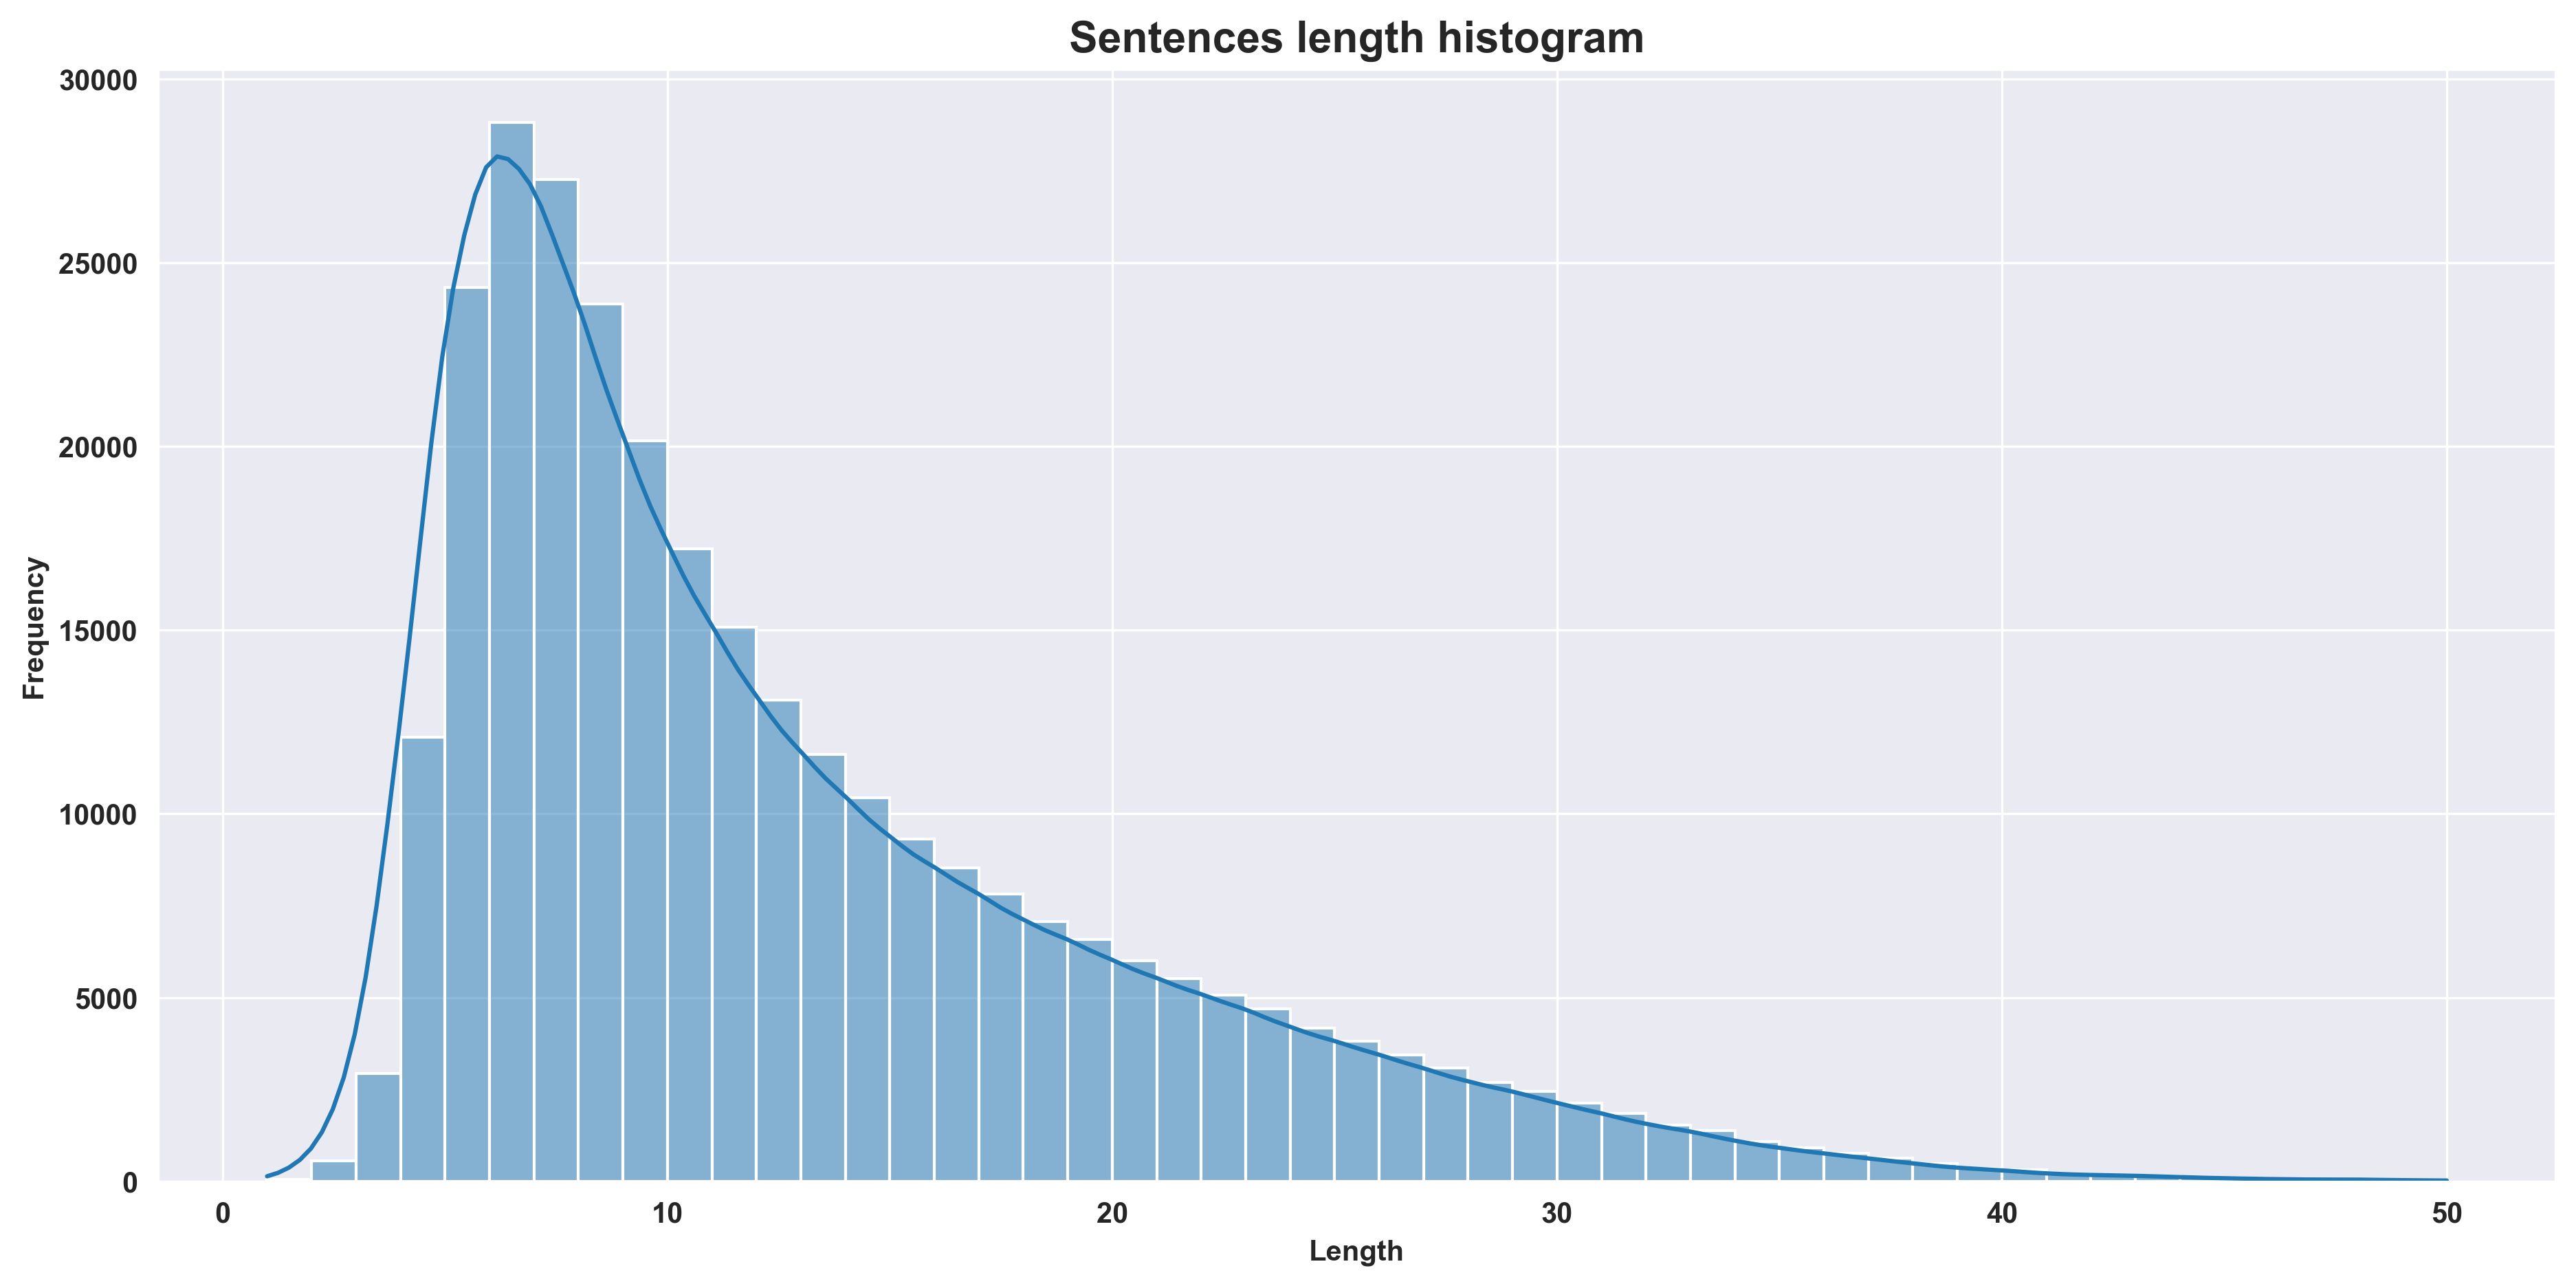

In [12]:
sentences_length(envi_data['en_words_count'])

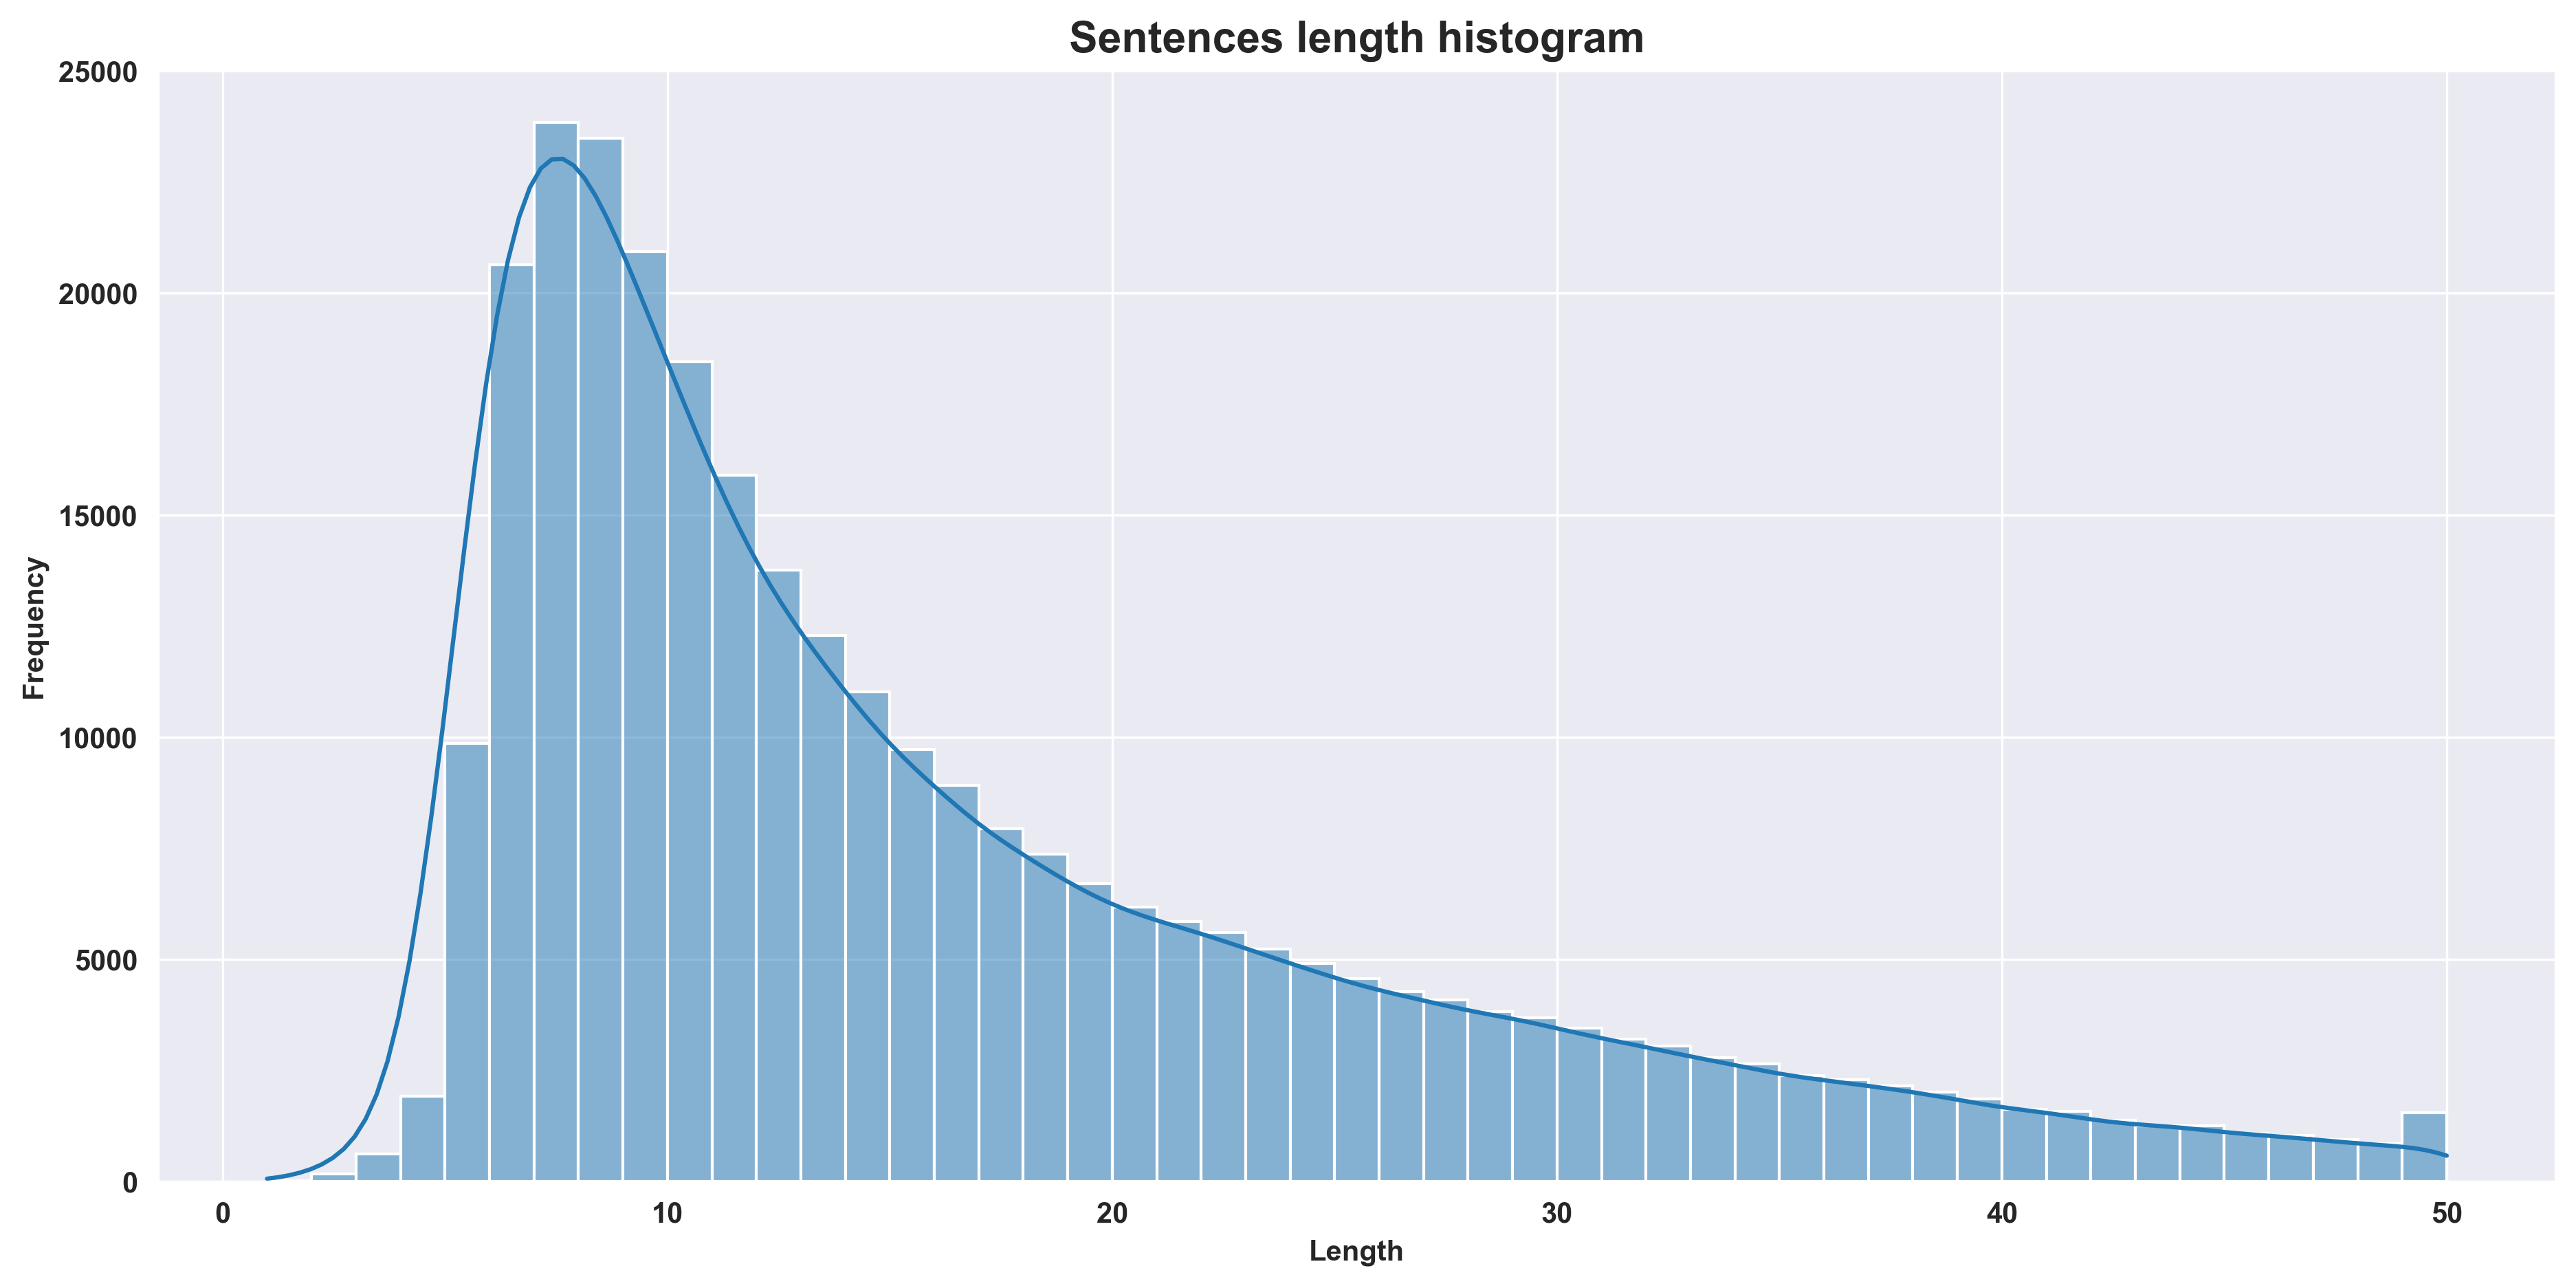

In [13]:
sentences_length(envi_data['vi_words_count'])

These histograms illustrate how sentence lengths are distributed in our dataset. They peak around 5–10 words and gradually taper off toward the 50-word limit, creating a right-skewed shape. In other words, most sentences are relatively short, and only a smaller fraction extend into higher word counts.

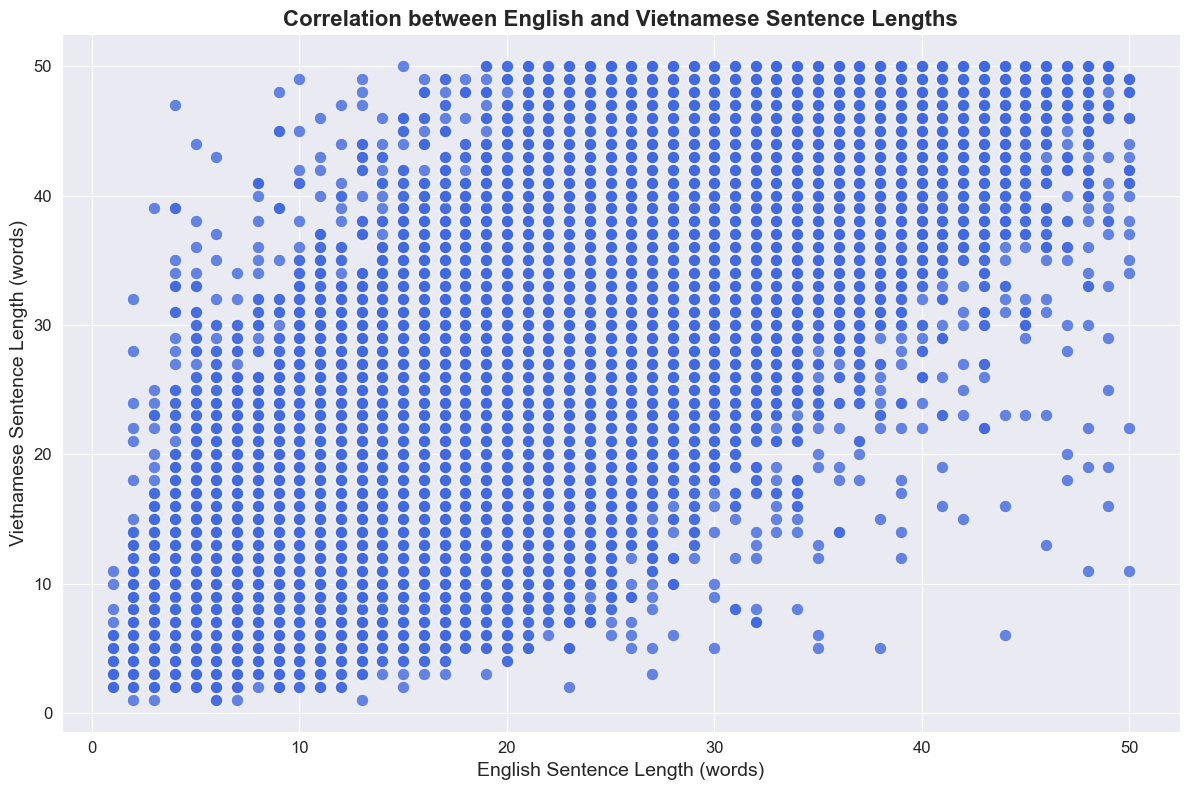

Correlation Matrix:
                 en_words_count  vi_words_count
en_words_count        1.000000        0.916643
vi_words_count        0.916643        1.000000


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style and figure size for better visuals
sns.set_style('darkgrid')
plt.figure(figsize=(12, 8))

# Create a scatter plot with customized markers, colors, and transparency
scatter = sns.scatterplot(
    data=envi_data,
    x='en_words_count',
    y='vi_words_count',
    color='royalblue',
    edgecolor='w',
    s=80,        # Marker size
    alpha=0.8,   # Marker transparency
    marker='o'
)

# Set axis labels and title with increased font sizes and bold title
plt.xlabel("English Sentence Length (words)", fontsize=14)
plt.ylabel("Vietnamese Sentence Length (words)", fontsize=14)
plt.title("Correlation between English and Vietnamese Sentence Lengths", fontsize=16, weight='bold')

# Adjust tick label sizes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

# Compute and print the correlation matrix
correlation = envi_data[['en_words_count', 'vi_words_count']].corr()
print("Correlation Matrix:\n", correlation)


These figures show a strong positive correlation between English and Vietnamese sentence lengths, with a correlation coefficient of approximately 0.92. As the length of an English sentence increases, the corresponding Vietnamese sentence tends to be longer as well. The scatter plot visually reinforces this relationship, while the correlation matrix quantifies it.

**Word Frequency**

In [15]:
import string
from collections import Counter

# Remove the apostrophe from the punctuation string
punctuation_to_remove = string.punctuation.replace("'", "")

# Create a translation table that maps the selected punctuation to None
translator = str.maketrans('', '', punctuation_to_remove)

# Join sentences into one text for each language
english_text = " ".join(envi_data["en"])
vietnamese_text = " ".join(envi_data["vi"])

# Remove punctuation from the texts (the apostrophe is preserved)
english_text = english_text.translate(translator)
vietnamese_text = vietnamese_text.translate(translator)

# Split the texts into words
english_words = english_text.split()
vietnamese_words = vietnamese_text.split()

# Count the occurrences of each word
english_counter = Counter(english_words)
vietnamese_counter = Counter(vietnamese_words)


In [16]:
# english_counter

In [17]:
# vietnamese_counter

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from wordcloud import STOPWORDS

def plot_top_words_bar_chart(word_freq):
    """
    Plots a bar chart for the top 10 words in the given frequency dictionary using Seaborn.
    
    This function filters out common stopwords from the word frequency dictionary, sorts 
    the remaining words by frequency, extracts the top 10, and plots a bar chart with a 
    Seaborn color palette. The plot is styled for better aesthetics.
    
    Args:
        word_freq (dict): A dictionary of word frequencies {word: frequency}
    """
    # Remove stopwords (ignoring case)
    filtered_word_freq = {word: freq for word, freq in word_freq.items() if word.lower() not in STOPWORDS}
    
    # Sort the dictionary by frequency and get the top 10 words (in descending order)
    sorted_words = sorted(filtered_word_freq.items(), key=lambda x: x[1], reverse=True)[:10]
    words, frequencies = zip(*sorted_words)
    
    # Create a DataFrame to facilitate plotting with Seaborn
    df = pd.DataFrame({'Word': words, 'Frequency': frequencies})
    
    # Sort the DataFrame for consistent bar order in the plot (highest on the left)
    df = df.sort_values(by='Frequency', ascending=False)
    
    # Set Seaborn style for a clean, modern look
    sns.set_style("darkgrid")
    plt.figure(figsize=(10, 8))
    
    # Create the barplot with 'Word' assigned to both x and hue to fix the palette deprecation warning.
    ax = sns.barplot(x='Word', y='Frequency', hue='Word', data=df, palette='magma', dodge=False)
    if ax.get_legend() is not None:
        ax.legend_.remove()  # Remove the legend as it is redundant
    
    # Enhance plot appearance with labels and title
    plt.title("Top 10 Word Occurrences", fontsize=16, weight='bold')
    plt.xlabel("Words", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xticks(rotation=0, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
    plt.show()


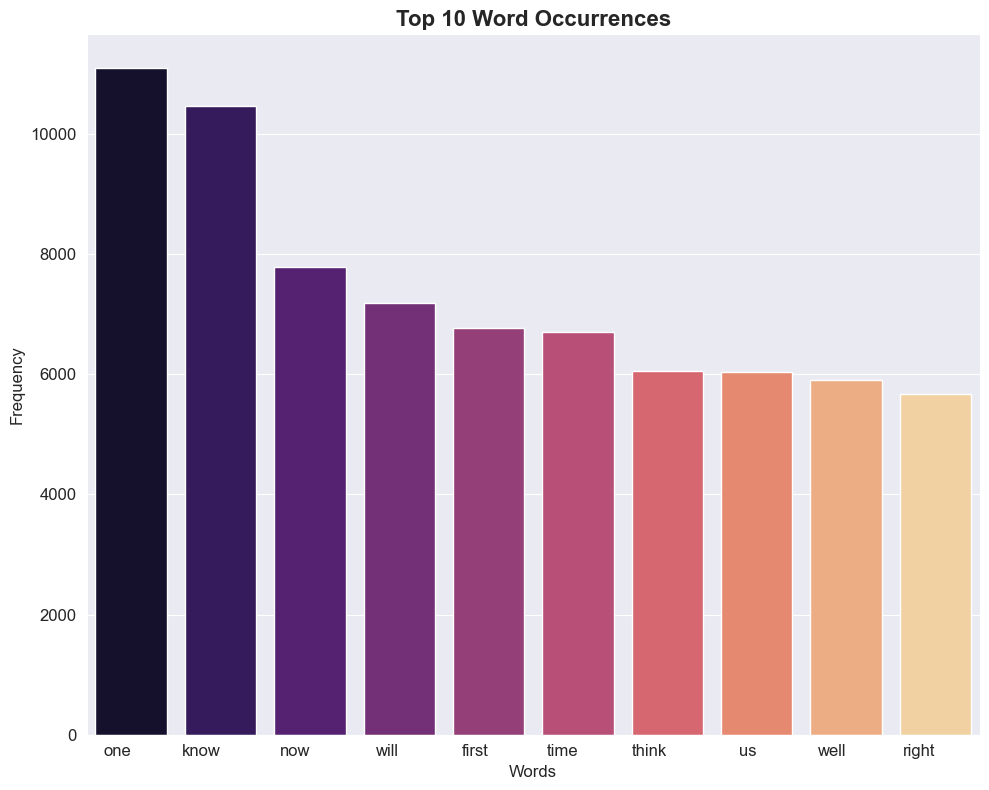

In [19]:
plot_top_words_bar_chart(english_counter)

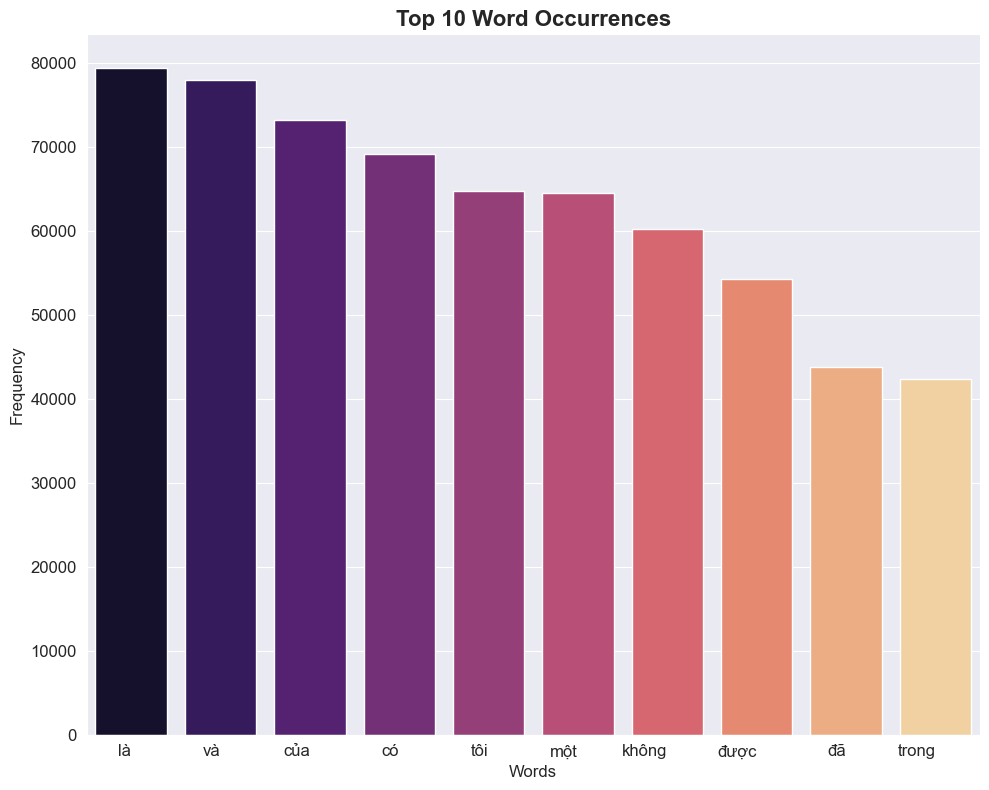

In [20]:
plot_top_words_bar_chart(vietnamese_counter)

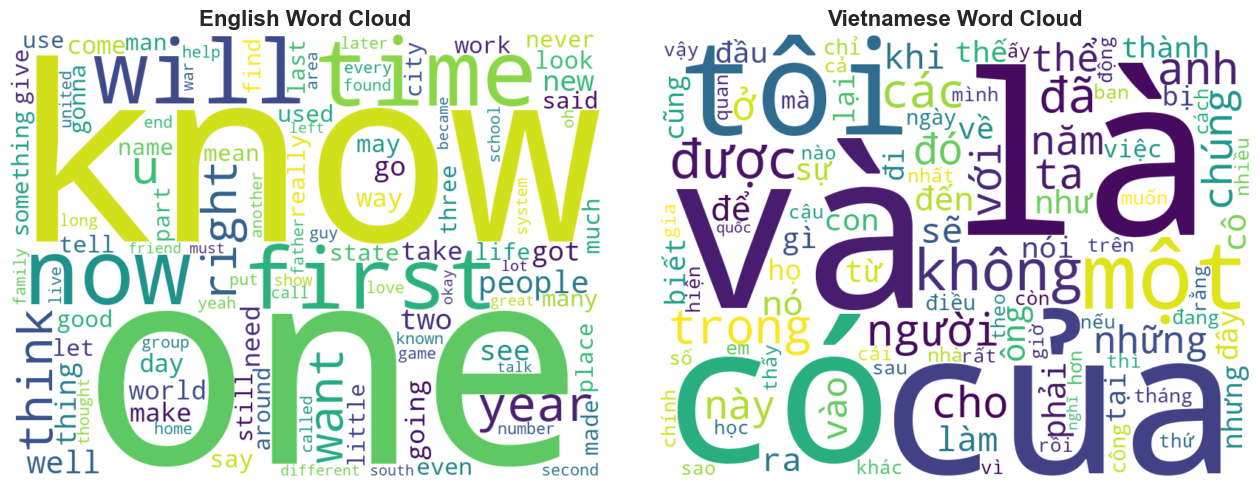

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create an enhanced English Word Cloud
english_wc = WordCloud(
    width=800,
    height=600,
    background_color="white",
    max_words=100,
    colormap="viridis",    # A vibrant colormap
    collocations=False,    # Disable collocations to prevent duplicate phrases
    contour_width=2,       # Add a subtle contour line
    contour_color="steelblue"
).generate(english_text)

# Create an enhanced Vietnamese Word Cloud
vietnamese_wc = WordCloud(
    width=800,
    height=600,
    background_color="white",
    max_words=100,
    colormap="viridis",      # A distinct colormap for variety
    collocations=False,
    contour_width=2,
    contour_color="steelblue"
).generate(vietnamese_text)

# Set up the figure for side-by-side plots
plt.figure(figsize=(16, 8))

# Plot the English word cloud
plt.subplot(1, 2, 1)
plt.imshow(english_wc, interpolation="bilinear")
plt.axis("off")
plt.title("English Word Cloud", fontsize=16, weight="bold")

# Plot the Vietnamese word cloud
plt.subplot(1, 2, 2)
plt.imshow(vietnamese_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Vietnamese Word Cloud", fontsize=16, weight="bold")

plt.subplots_adjust(wspace=0.1)
plt.show()


These three figures display the most frequently used words in the English and Vietnamese portions of the dataset. In the English word cloud, terms like “one,” “know,” and “now” stand out, while in the Vietnamese word cloud, “và,” “là,” and “của” dominate. Many of these are high-frequency function words, reflecting the foundational elements of each language rather than specific thematic content.

### **N-gram Analysis**

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

In [23]:
def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

In [24]:
top_en_bigram = get_top_ngram(envi_data['en'], n=2)
top_en_trigram = get_top_ngram(envi_data['en'], n=3)

In [25]:
top_vi_bigram = get_top_ngram(envi_data['vi'], n=2)
top_vi_trigram = get_top_ngram(envi_data['vi'], n=3)

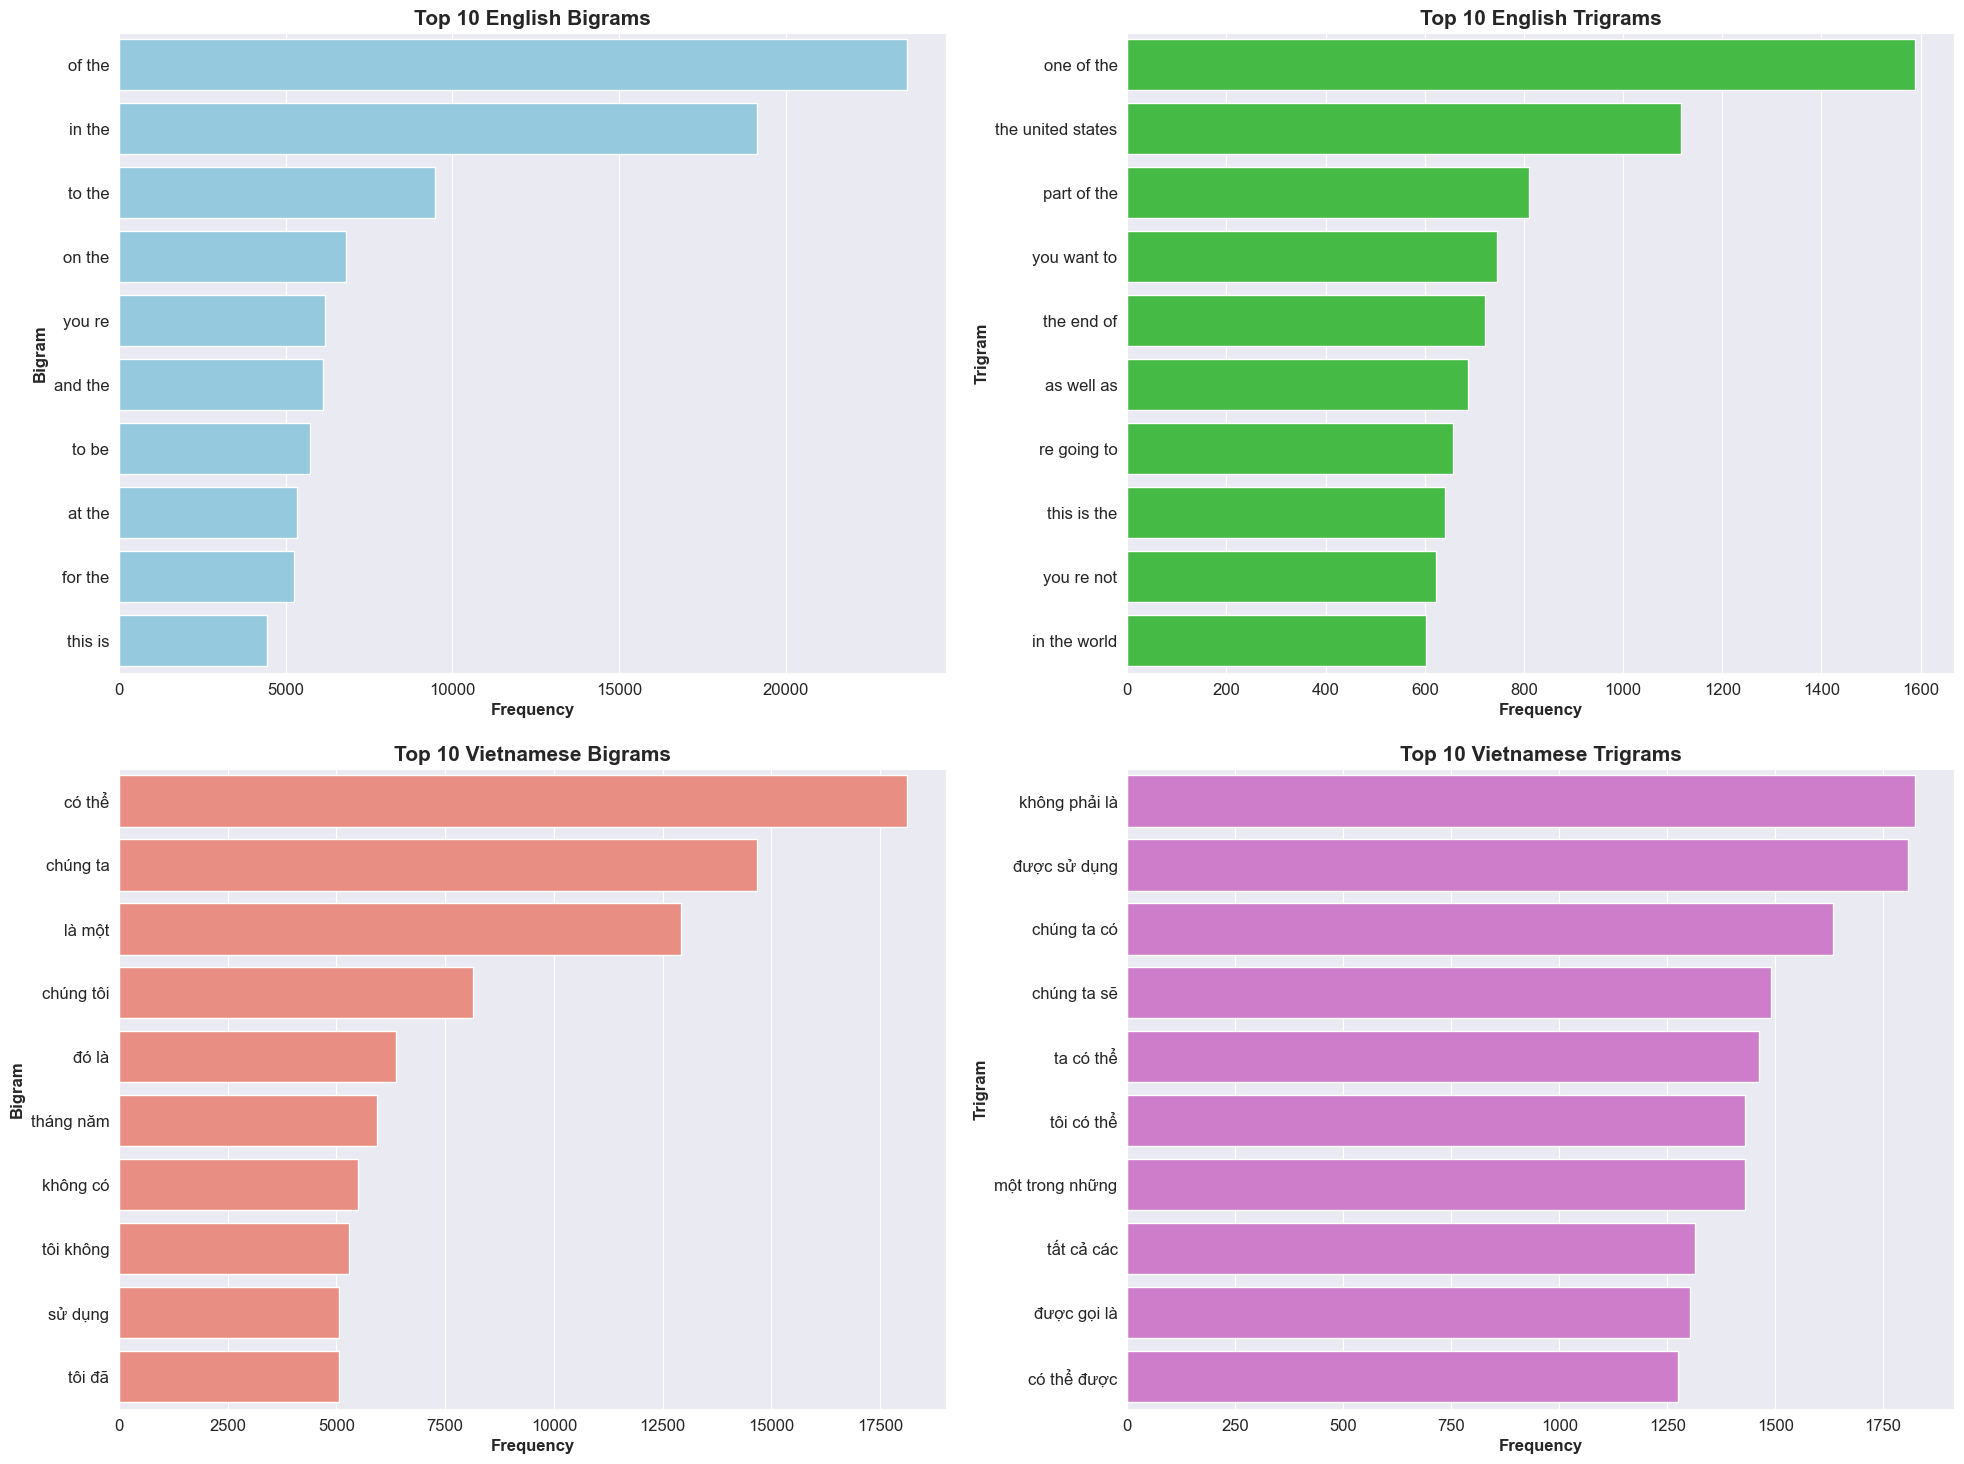

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean Seaborn style
sns.set_style("darkgrid")

# Create a 2x2 grid of subplots with increased figure size
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# --- Top 10 English Bigrams ---
en_bigram_words, en_bigram_freq = map(list, zip(*top_en_bigram))
sns.barplot(x=en_bigram_freq, y=en_bigram_words, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Bigram', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Top 10 English Bigrams', fontsize=15, fontweight='bold')
axes[0, 0].tick_params(axis='both', labelsize=12)

# --- Top 10 English Trigrams ---
en_trigram_words, en_trigram_freq = map(list, zip(*top_en_trigram))
sns.barplot(x=en_trigram_freq, y=en_trigram_words, color='limegreen', ax=axes[0, 1])
axes[0, 1].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Trigram', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Top 10 English Trigrams', fontsize=15, fontweight='bold')
axes[0, 1].tick_params(axis='both', labelsize=12)

# --- Top 10 Vietnamese Bigrams ---
vi_bigram_words, vi_bigram_freq = map(list, zip(*top_vi_bigram))
sns.barplot(x=vi_bigram_freq, y=vi_bigram_words, color='salmon', ax=axes[1, 0])
axes[1, 0].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Bigram', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Top 10 Vietnamese Bigrams', fontsize=15, fontweight='bold')
axes[1, 0].tick_params(axis='both', labelsize=12)

# --- Top 10 Vietnamese Trigrams ---
vi_trigram_words, vi_trigram_freq = map(list, zip(*top_vi_trigram))
sns.barplot(x=vi_trigram_freq, y=vi_trigram_words, color='orchid', ax=axes[1, 1])
axes[1, 1].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Trigram', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Top 10 Vietnamese Trigrams', fontsize=15, fontweight='bold')
axes[1, 1].tick_params(axis='both', labelsize=12)

# Adjust spacing between subplots for clarity
plt.tight_layout(pad=2.0)
plt.show()



These bar charts highlight the most frequent bigrams and trigrams in both English and Vietnamese texts. In English, phrases like “of the,” “in the,” and “to the” dominate the bigrams, while trigrams often include prepositional structures such as “the united states” and “part of the.” Similarly, the Vietnamese charts reveal commonly repeated function words and short phrases, reflecting typical grammatical and usage patterns. Examining these high‐frequency n‐grams helps illustrate how each language structures sentences and conveys common ideas.
